1. Install & Import Libraries

In [25]:
# nltk for NLP preprocessing
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
# Removed explicit jax installation to avoid conflicts with pre-installed TensorFlow

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# Import time module to measure model training duration
import time
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

#2 Load Dataset

The dataset contains:
- headline: News headline text
- category: Corresponding category label

The objective is to classify headlines into their respective categories.



In [27]:
# Mount Google Drive to access the dataset. This allows the Colab environment to access files stored in your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
# Make sure to upload 'news_category.csv' directly to your Colab environment's '/content/' folder for this to work.
# You can do this by clicking the folder icon on the left sidebar, navigating to 'content', and then uploading the file.
file_path = "/content/drive/My Drive/ai/News Category Dataset/news_category.csv"

# Load the dataset into a pandas DataFrame
news_dataframe = pd.read_csv(file_path)

# Keep only the 'headline' and 'category' columns, as they are needed for our task
news_dataframe = news_dataframe[['headline', 'category']]

# Display the first few rows to understand the data structure
print("First 5 rows of the dataset:")
display(news_dataframe.head())

# Print the shape of the dataset (number of rows, number of columns)
print("Dataset shape:", news_dataframe.shape)
# Print the number of unique categories to understand the classification task
print("Number of classes:", news_dataframe['category'].nunique())
# Show the distribution of headlines across different categories
print("Category distribution:")
print(news_dataframe['category'].value_counts())

First 5 rows of the dataset:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


Dataset shape: (11025, 2)
Number of classes: 5
Category distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


## Dataset Class Distribution

This cell visualizes how many samples are available in each category. This is important because imbalanced classes can affect model performance.

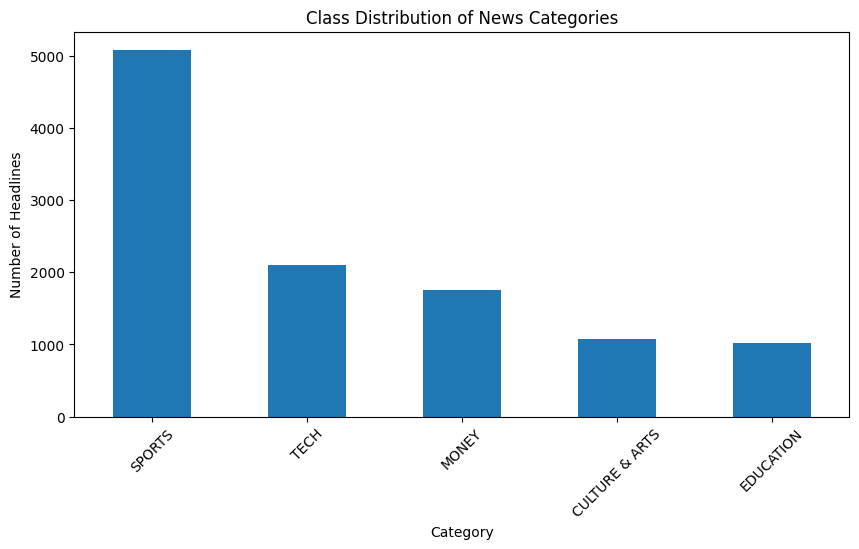

In [29]:
# Plot the number of headlines in each category
plt.figure(figsize=(10, 5))

# Count how many headlines belong to each category and create a bar chart
news_dataframe['category'].value_counts().plot(kind='bar')

# Add title and labels for clear understanding
plt.title('Class Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Headlines')

# Rotate x-axis labels for readability, especially if category names are long
plt.xticks(rotation=45)

# Display the plot
plt.show()

3. Text Preprocessing
Preprocessing steps include:
- Lowercasing text
- Removing URLs, mentions, hashtags, and special characters
- Removing stopwords
- Applying lemmatization

These steps improve model performance by reducing noise.


## Sample of News Category Dataset

This section displays a small sample of the dataset used in this project. The dataset contains news headlines and their corresponding category labels.

In [30]:
# Display the first 10 rows of the dataset
# This helps us understand the structure and content of the news headlines and their categories

sample_news_dataframe = news_dataframe[['headline', 'category']].head(10)

# Show the sample DataFrame
display(sample_news_dataframe)

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


In [31]:
# Contraction mapping for expanding common English contractions like "don't" to "do not"
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "n't": " not", "'re": " are", "'s": " is", "'ll": " will",
    "'ve": " have", "'m": " am", "'d": " would", "ain't": "am not",
    "let's": "let us", "couldn't": "could not", "wouldn't": "would not",
    "shouldn't": "should not", "doesn't": "does not", "didn't": "did not"
}

def expand_contractions(raw_text: str) -> str:
    """Replace contractions with full forms (e.g., 'don't' -> 'do not')."""
    processed_text = raw_text
    for short_form, full_form in CONTRACTIONS.items():
        processed_text = processed_text.replace(short_form, full_form)
    return processed_text

# Initialize stopwords (common words like 'a', 'the', 'is' that are often removed)
english_stopwords = set(stopwords.words('english'))
# Initialize WordNetLemmatizer for reducing words to their base form (e.g., 'running' -> 'run')
word_lemmatizer = WordNetLemmatizer()

def clean_text(raw_text):
    """
    Cleans raw text by removing noise and normalizing words.
    Steps: lowercasing, contraction expansion, removal of URLs/mentions/hashtags/special chars,
    tokenization, stopword removal, and lemmatization.
    """
    # Convert text to lowercase to ensure consistency
    text_lower = str(raw_text).lower()
    # Expand contractions like "don't" to "do not"
    text_expanded = expand_contractions(text_lower)

    # Remove unwanted patterns using regular expressions
    text_no_urls = re.sub(r"http\S+", "", text_expanded)             # Remove URLs (e.g., https://example.com)
    text_no_mentions = re.sub(r"@\w+", "", text_no_urls)                # Remove mentions (e.g., @username)
    text_no_hashtags = re.sub(r"#\w+", "", text_no_mentions)              # Remove hashtags (e.g., #topic)
    # Remove any characters that are not letters or spaces
    text_only_letters = re.sub(r"[^a-zA-Z\s]", "", text_no_hashtags)

    # Split the text into individual words (tokenization)
    words = text_only_letters.split()

    # Remove stopwords and apply lemmatization to each word
    # Only keep words that are not in the English stopwords list
    # Then, reduce each word to its base form (lemma)
    processed_words = [word_lemmatizer.lemmatize(word) for word in words if word not in english_stopwords]

    # Join the processed words back into a single string
    return " ".join(processed_words)

# Apply the cleaning function to the 'headline' column and store the results in a new 'clean_text' column
news_dataframe['clean_text'] = news_dataframe['headline'].apply(clean_text)

Word Cloud Visualization

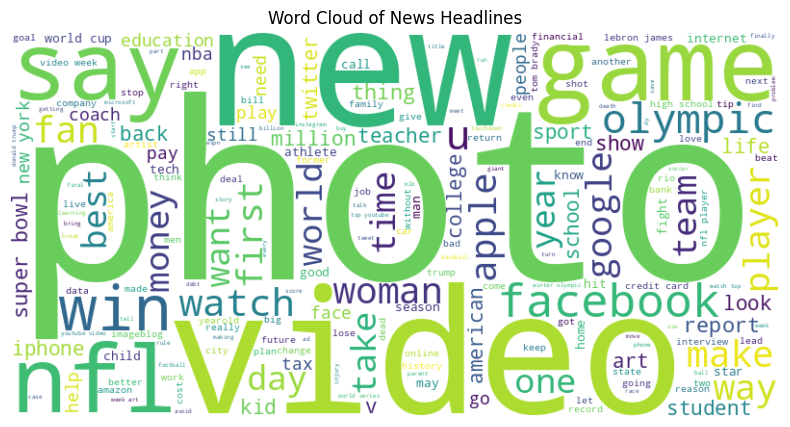

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text from the 'clean_text' column into one large string
# This string will be used to generate the word cloud
combined_cleaned_headlines = " ".join(news_dataframe['clean_text'])

# Generate the word cloud. Common words will appear larger.
headline_wordcloud = WordCloud(
    width=800,           # Width of the generated image
    height=400,          # Height of the generated image
    background_color='white' # Background color of the word cloud
).generate(combined_cleaned_headlines)

# Display the generated word cloud
plt.figure(figsize=(10, 5)) # Set the size of the plot
plt.imshow(headline_wordcloud, interpolation='bilinear') # Display the image
plt.axis('off') # Hide the axes
plt.title('Word Cloud of News Headlines') # Add a title to the plot
plt.show()

4. Tokenization & Encoding


Text is converted into numerical sequences using a tokenizer.

Padding ensures uniform sequence length using the 95th percentile to avoid extremely long inputs.

Labels are encoded using LabelEncoder for multi-class classification.

In [33]:
# TOKENIZATION: Convert cleaned text into a numerical format that machine learning models can understand

# Create a Tokenizer. It will consider the top 10000 most frequent words.
# '<OOV>' (Out Of Vocabulary) token will be used for words not in the top 10000.
text_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Learn the vocabulary (word-to-index mapping) from our cleaned headlines
text_tokenizer.fit_on_texts(news_dataframe['clean_text'])

# Convert each headline into a sequence of integer word indexes
tokenized_headlines = text_tokenizer.texts_to_sequences(news_dataframe['clean_text'])

# Determine the maximum sequence length for padding.
# We use the 95th percentile length to avoid very long sequences and keep computation efficient.
max_sequence_length = int(np.percentile([len(s) for s in tokenized_headlines], 95))

# Ensure the maximum sequence length is at least 1, to prevent errors with very short texts
max_sequence_length = max(max_sequence_length, 1)

# Pad all tokenized headline sequences to the same length (max_sequence_length).
# 'post' padding adds zeros at the end. 'post' truncating removes words from the end if too long.
padded_sequences = pad_sequences(tokenized_headlines, maxlen=max_sequence_length, padding='post', truncating='post')

# Encode category labels (e.g., 'SPORTS', 'TECH') into numerical representations (0, 1, 2, ...)
category_label_encoder = LabelEncoder()
encoded_labels = category_label_encoder.fit_transform(news_dataframe['category'])

# Get the number of unique output classes/categories
number_of_classes = len(category_label_encoder.classes_)

# Determine the vocabulary size for the embedding layer. It's the number of unique words + 1 (for padding).
vocabulary_size = min(10000, len(text_tokenizer.word_index) + 1)

# Split the data into training and testing sets.
# 'stratify=encoded_labels' ensures that the class distribution is similar in both sets.
train_sequences, test_sequences, train_labels, test_labels = train_test_split(
    padded_sequences,      # The padded numerical headline sequences
    encoded_labels,        # The numerical category labels
    test_size=0.2,         # 20% of the data for testing
    random_state=42,       # For reproducibility of the split
    stratify=encoded_labels # Maintain class proportions
)

print("Maximum sequence length:", max_sequence_length)
print("Vocabulary size:", vocabulary_size)
print("Number of classes:", number_of_classes)
print("Classes (original names):", category_label_encoder.classes_)
print("Number of training samples:", train_sequences.shape[0])
print("Number of testing samples:", test_sequences.shape[0])

Maximum sequence length: 11
Vocabulary size: 10000
Number of classes: 5
Classes (original names): ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']
Number of training samples: 8820
Number of testing samples: 2205


5. Model 1: Simple RNN


This model uses a Simple Recurrent Neural Network to capture sequential dependencies in text.

However, RNNs suffer from vanishing gradient problems, which limits their ability to learn long-term dependencies.

In [34]:
# MODEL 1: SIMPLE RNN (Recurrent Neural Network)

# Create a Sequential model, which builds layers in a linear stack
simple_rnn_model = Sequential()

# Embedding layer:
# It converts positive integer indices (words) into dense vectors of fixed size (64 dimensions).
# input_dim: size of the vocabulary (number of unique words).
# output_dim: dimension of the dense embedding.
simple_rnn_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=64
))

# SimpleRNN layer:
# This is a basic recurrent layer that processes sequences. It has 64 units.
simple_rnn_model.add(SimpleRNN(64))

# Output layer:
# A Dense layer with 'number_of_classes' units (one for each category).
# 'softmax' activation ensures that the output probabilities sum to 1, useful for multi-class classification.
simple_rnn_model.add(Dense(number_of_classes, activation='softmax'))

# Build the model with a specified input shape (None for batch size, max_sequence_length for text length)
simple_rnn_model.build(input_shape=(None, max_sequence_length))

# Compile the model:
# loss: 'sparse_categorical_crossentropy' is used because our labels are integers (not one-hot encoded).
# optimizer: 'adam' is an efficient optimization algorithm.
# metrics: 'accuracy' will be monitored during training.
simple_rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display a summary of the model's architecture, including layer types, output shapes, and number of parameters.
simple_rnn_model.summary()

# Start timer to measure how long the training takes
start_time = time.time()

# Train the model:
# X_train: training input sequences.
# y_train: training labels.
# validation_split: 20% of training data will be used for validation during training.
# epochs: Number of times the model will go through the entire training dataset.
# batch_size: Number of samples processed before the model's parameters are updated.
# callbacks: EarlyStopping monitors 'val_loss' and stops training if it doesn't improve for 2 epochs.
#            'restore_best_weights=True' keeps the model weights from the best performing epoch.
rnn_training_history = simple_rnn_model.fit(
    train_sequences,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(
        patience=2,
        restore_best_weights=True
    )]
)

# End timer and calculate total training time
simple_rnn_training_time = time.time() - start_time

print("Simple RNN Training Time:", round(simple_rnn_training_time, 2), "seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,581 (2.47 MB)

 Trainable params: 648,581 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6580 - loss: 0.9241 - val_accuracy: 0.7954 - val_loss: 0.6033
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9015 - loss: 0.3101 - val_accuracy: 0.7925 - val_loss: 0.6390
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9660 - loss: 0.1174 - val_accuracy: 0.7920 - val_loss: 0.6908
Simple RNN Training Time: 11.59 seconds


6. Model 2: LSTM


### Model 2: LSTM

LSTM (Long Short-Term Memory) networks are designed to overcome the limitations of RNNs.

They can capture long-term dependencies using memory cells and gating mechanisms, making them more effective for text classification.

In [35]:
# MODEL 2: LSTM (Long Short-Term Memory Network)
# LSTMs are a type of RNN designed to better capture long-term dependencies in sequences.

# Create a Sequential model
lstm_text_model = Sequential()

# Embedding layer: Converts word indices into dense vectors
# input_dim: size of the vocabulary
# output_dim: dimension of the dense embedding (64 here)
lstm_text_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=64
))

# LSTM layer: Processes the sequence and captures long-term patterns.
# It has 64 units, which is a common choice for hidden state size.
lstm_text_model.add(LSTM(64))

# Output layer: A Dense layer for multi-class classification
# number_of_classes: corresponds to the number of unique news categories
# 'softmax' activation: provides probabilities for each class, summing to 1
lstm_text_model.add(Dense(number_of_classes, activation='softmax'))

# Build the model with a specified input shape
lstm_text_model.build(input_shape=(None, max_sequence_length))

# Compile the model:
# loss: 'sparse_categorical_crossentropy' for integer labels
# optimizer: 'adam' for efficient gradient descent
# metrics: 'accuracy' to monitor performance during training
lstm_text_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display the model's architecture summary
lstm_text_model.summary()

# Start timer to track training duration
start_time = time.time()

# Train the LSTM model with early stopping
# validation_split: 20% of the training data is used for validation
# epochs: maximum number of training iterations
# batch_size: number of samples per gradient update
# callbacks: EarlyStopping monitors 'val_loss' and stops if no improvement after 2 epochs,
#            restoring the best weights found.
lstm_training_history = lstm_text_model.fit(
    train_sequences,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(
        patience=2,
        restore_best_weights=True
    )]
)

# End timer and calculate the total training time for the LSTM model
lstm_training_time = time.time() - start_time

print("LSTM Training Time:", round(lstm_training_time, 2), "seconds")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,349 (2.57 MB)

 Trainable params: 673,349 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5944 - loss: 1.0356 - val_accuracy: 0.7273 - val_loss: 0.7196
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8431 - loss: 0.4390 - val_accuracy: 0.8424 - val_loss: 0.4634
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9452 - loss: 0.1761 - val_accuracy: 0.8345 - val_loss: 0.5071
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9769 - loss: 0.0811 - val_accuracy: 0.8407 - val_loss: 0.5964
LSTM Training Time: 16.04 seconds


7. Model 3: Pretrained GloVe Embedding + LSTM

This model uses pretrained GloVe embeddings from gensim. Although the assignment mentions Word2Vec, GloVe is also a pretrained word embedding technique and is loaded from the provided gensim API.

In [36]:
import sys

# Install gensim in Google Colab if it's not already installed
# This is a conditional installation, only runs if in Colab environment.
if 'google.colab' in sys.modules:
    %pip install gensim

import gensim.downloader as api
import numpy as np # Import numpy if not already imported in this scope

# Load a pretrained GloVe word embedding model (50-dimensional vectors)
# GloVe (Global Vectors for Word Representation) provides pre-trained word vectors.
glove_word_vectors = api.load('glove-wiki-gigaword-50')

# The dimension of the word vectors from the GloVe model is 50
glove_embedding_dimension = 50

# Create an embedding matrix initialized with zeros.
# This matrix will hold the word vectors for our vocabulary.
glove_embedding_matrix = np.zeros((vocabulary_size, glove_embedding_dimension))

# Fill the embedding matrix with pretrained GloVe vectors where available.
# For each word in our tokenizer's vocabulary, if it exists in GloVe, copy its vector.
for word, index in text_tokenizer.word_index.items():
    # Ensure the word's index is within our defined vocabulary size
    if index < vocabulary_size:
        # Check if the word exists in the pretrained GloVe model
        if word in glove_word_vectors:
            glove_embedding_matrix[index] = glove_word_vectors[word]

# MODEL 3: LSTM WITH PRETRAINED GLOVE EMBEDDING
# This model uses the GloVe embeddings we just prepared.

glove_lstm_model = Sequential()

# Pretrained Embedding layer:
# input_dim: size of our vocabulary.
# output_dim: dimension of the GloVe vectors (50).
# weights: initialized with our 'glove_embedding_matrix'.
# input_length: maximum length of input sequences.
# trainable=False: This is crucial! It means the GloVe embeddings will not be updated during training.
#                  We are using them as a fixed feature representation.
glove_lstm_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=glove_embedding_dimension,
    weights=[glove_embedding_matrix],
    input_length=max_sequence_length,
    trainable=False
))

# LSTM layer: Learns sequential patterns from the (now fixed) GloVe embeddings.
glove_lstm_model.add(LSTM(64))

# Output layer: Dense layer for multi-class classification with 'softmax' activation.
glove_lstm_model.add(Dense(number_of_classes, activation='softmax'))

# Compile the model:
# loss: 'sparse_categorical_crossentropy' for integer labels.
# optimizer: 'adam'.
# metrics: 'accuracy'.
glove_lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display the model's architecture summary
glove_lstm_model.summary()

# Start timer to measure training duration
start_time = time.time()

# Train the model with early stopping, similar to previous models
glove_lstm_training_history = glove_lstm_model.fit(
    train_sequences,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

# End timer and calculate training time
glove_lstm_training_time = time.time() - start_time

print("Pretrained GloVe LSTM Training Time:", round(glove_lstm_training_time, 2), "seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7421 - loss: 0.7213 - val_accuracy: 0.8186 - val_loss: 0.5192
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8335 - loss: 0.4801 - val_accuracy: 0.8265 - val_loss: 0.4744
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8523 - loss: 0.4319 - val_accuracy: 0.8367 - val_loss: 0.4546
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8651 - loss: 0.4028 - val_accuracy: 0.8418 - val_loss: 0.4378
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8743 - loss: 0.3667 - val_accuracy: 0.8469 - val_loss: 0.4288
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8844 - loss: 0.3415 - val_accuracy: 0.8430 - val_loss: 0.4320
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8943 - loss: 0.3144 - val_accuracy: 0.8515 - val_loss: 0.4323
Pretrained GloVe LSTM Training Time: 17.65 seconds


8. Evaluation


The models are evaluated using:
- Accuracy
- Confusion Matrix
- Precision, Recall, and F1-score

These metrics provide a comprehensive understanding of model performance.

In [37]:
# MODEL EVALUATION FUNCTION

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(model_to_evaluate, model_name):
    """
    Evaluates a trained model using accuracy, confusion matrix,
    precision, recall, and F1-score.
    """

    # Predict class probabilities for the test dataset
    predicted_probabilities = model_to_evaluate.predict(test_sequences)

    # Convert probabilities into final predicted class labels
    # np.argmax gets the index of the highest probability for each sample
    predicted_labels = np.argmax(predicted_probabilities, axis=1)

    print(f"\n--- {model_name} Results ---")

    # Calculate and print the overall accuracy score
    accuracy = accuracy_score(test_labels, predicted_labels)
    print("Accuracy:", round(accuracy, 4))

    # Print the Confusion Matrix, which shows counts of correct and incorrect predictions for each class
    print("\nConfusion Matrix:")
    print(confusion_matrix(test_labels, predicted_labels))

    # Print a detailed Classification Report including Precision, Recall, and F1-score for each class
    print("\nClassification Report:")
    print(classification_report(
        test_labels,                  # True labels from the test set
        predicted_labels,             # Predicted labels from the model
        target_names=category_label_encoder.classes_, # Use original category names for clarity
        zero_division=0               # Handle cases where division by zero might occur gracefully
    ))

    # Calculate weighted metrics (precision, recall, f1) for overall performance, suitable for imbalanced datasets
    # 'weighted' average considers the number of true instances for each label
    precision, recall, f1, _ = precision_recall_fscore_support(
        test_labels,
        predicted_labels,
        average='weighted',
        zero_division=0
    )

    return accuracy, precision, recall, f1


# Evaluate all three trained models and store their results
simple_rnn_results = evaluate_model(simple_rnn_model, "Simple RNN")
lstm_results = evaluate_model(lstm_text_model, "LSTM")
glove_lstm_results = evaluate_model(glove_lstm_model, "Pretrained GloVe LSTM")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- Simple RNN Results ---
Accuracy: 0.7841

Confusion Matrix:
[[126   2   6  58  23]
 [  2 116  10  25  50]
 [ 33  33 189  25  71]
 [  8   9   6 943  49]
 [  4  16  11  35 355]]

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.73      0.59      0.65       215
     EDUCATION       0.66      0.57      0.61       203
         MONEY       0.85      0.54      0.66       351
        SPORTS       0.87      0.93      0.90      1015
          TECH       0.65      0.84      0.73       421

      accuracy                           0.78      2205
     macro avg       0.75      0.69      0.71      2205
  weighted avg       0.79      0.78      0.78      2205

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- LSTM Results ---
Accuracy: 0.8317

Confusion Matrix:
[[166   4  19  21   5]
 [ 12 128  27  17  19]
 [ 13  26 266  23  23]
 [ 15  18   7 961  14]
 [ 16   8  29  55 313]]

Classification Report:
             

9. Plot Graphs

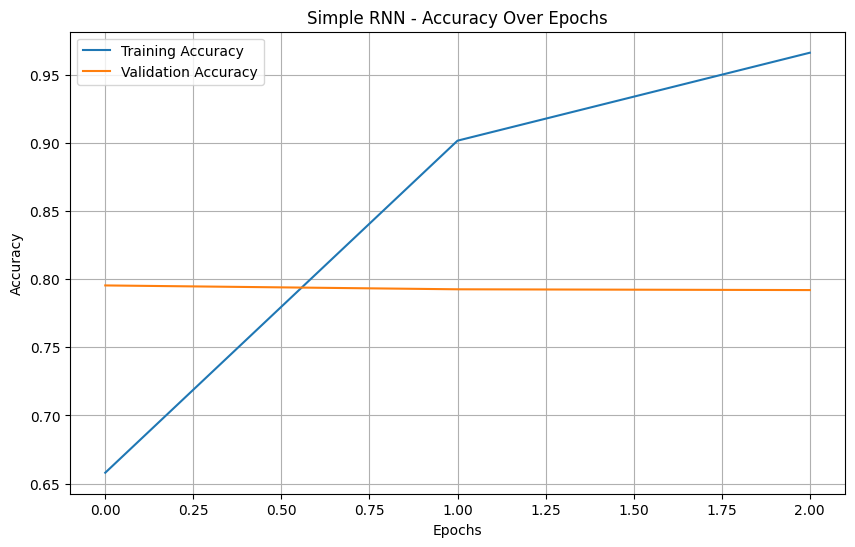

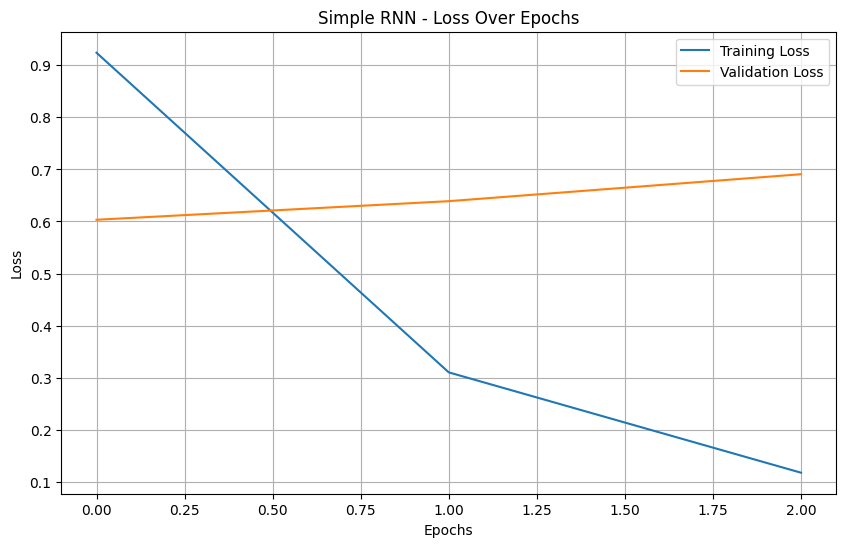

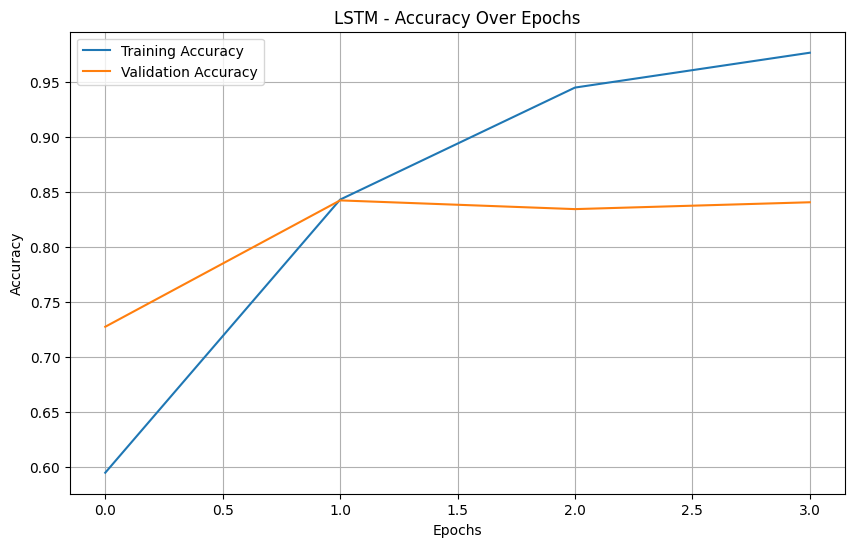

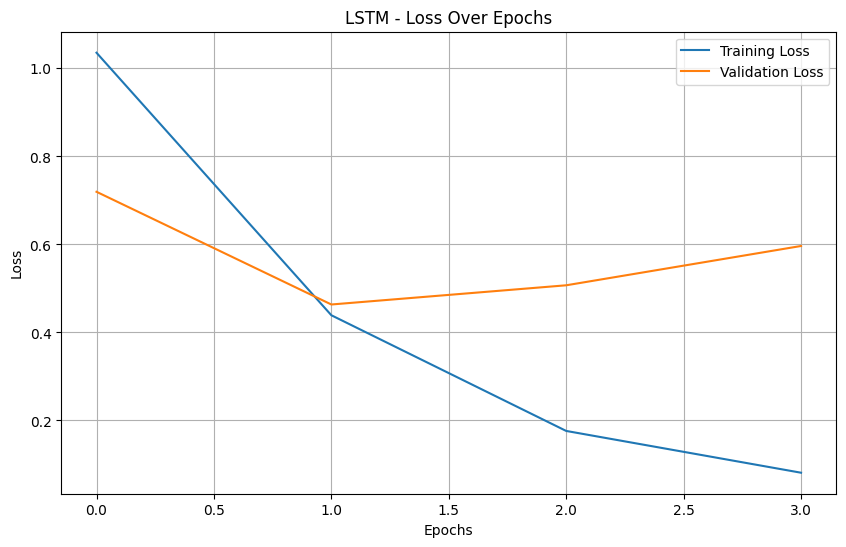

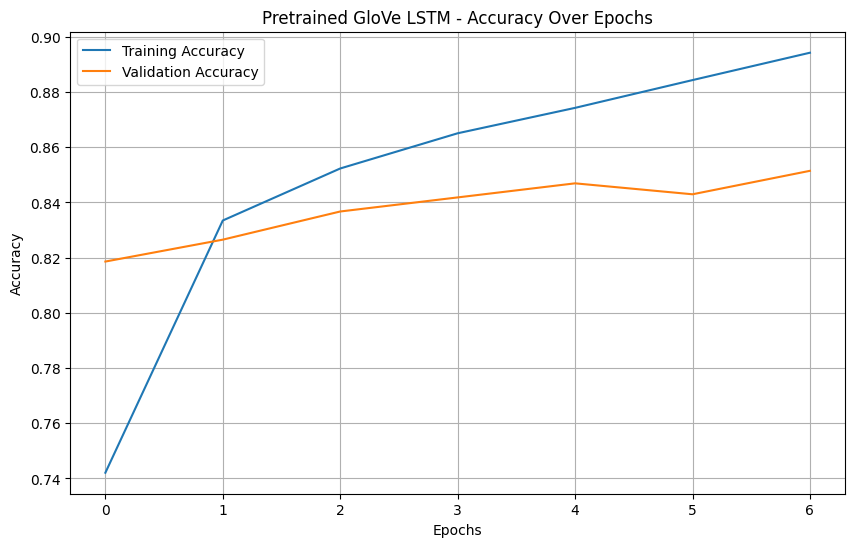

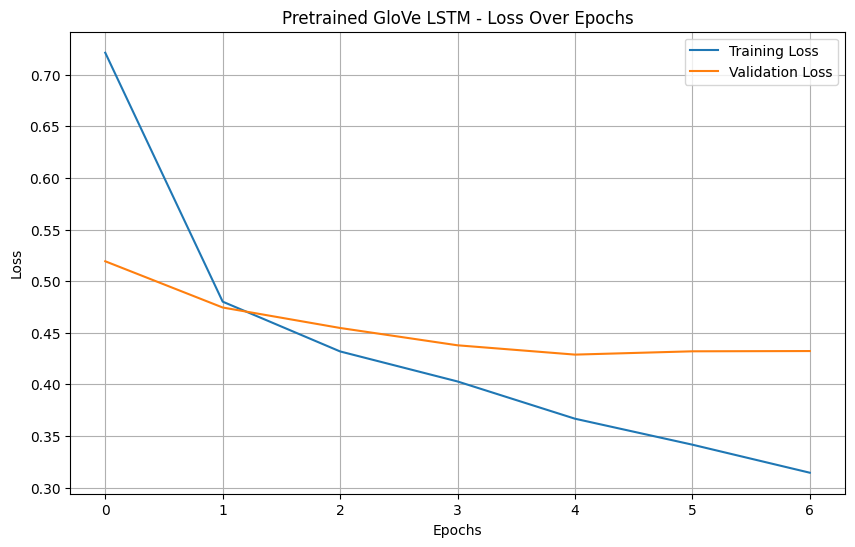

In [38]:
# VISUALIZE TRAINING ACCURACY AND LOSS

def plot_training_history(history_data, plot_title):
    """
    Plots training vs validation accuracy and loss over epochs.
    These graphs help visualize model learning and identify potential overfitting or underfitting.
    """

    # Plot for Accuracy
    plt.figure(figsize=(10, 6)) # Set a good figure size for the plot
    plt.plot(history_data.history['accuracy'], label='Training Accuracy')
    plt.plot(history_data.history['val_accuracy'], label='Validation Accuracy')
    plt.title(plot_title + ' - Accuracy Over Epochs') # Title for the accuracy plot
    plt.xlabel('Epochs') # Label for the x-axis
    plt.ylabel('Accuracy') # Label for the y-axis
    plt.legend() # Display legend to differentiate training and validation curves
    plt.grid(True) # Add a grid for better readability
    plt.show()

    # Plot for Loss
    plt.figure(figsize=(10, 6)) # Set a good figure size for the plot
    plt.plot(history_data.history['loss'], label='Training Loss')
    plt.plot(history_data.history['val_loss'], label='Validation Loss')
    plt.title(plot_title + ' - Loss Over Epochs') # Title for the loss plot
    plt.xlabel('Epochs') # Label for the x-axis
    plt.ylabel('Loss') # Label for the y-axis
    plt.legend() # Display legend
    plt.grid(True) # Add a grid
    plt.show()

# Call the plotting function for each model's training history
plot_training_history(rnn_training_history, "Simple RNN")
plot_training_history(lstm_training_history, "LSTM")
plot_training_history(glove_lstm_training_history, "Pretrained GloVe LSTM")

## Model Performance Comparison

This table compares all three models using accuracy, precision, recall, F1-score, and training time. This is required for the Experiments and Results section of the final report.

In [39]:
# Create a comparison table (Pandas DataFrame) to summarize the performance of all models
model_comparison_dataframe = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'Pretrained GloVe LSTM'],
    'Accuracy': [simple_rnn_results[0], lstm_results[0], glove_lstm_results[0]],
    'Precision': [simple_rnn_results[1], lstm_results[1], glove_lstm_results[1]],
    'Recall': [simple_rnn_results[2], lstm_results[2], glove_lstm_results[2]],
    'F1-score': [simple_rnn_results[3], lstm_results[3], glove_lstm_results[3]],
    'Training Time (seconds)': [simple_rnn_training_time, lstm_training_time, glove_lstm_training_time]
})

# Round the numerical values in the DataFrame to 4 decimal places for cleaner display
model_comparison_dataframe = model_comparison_dataframe.round(4)

# Display the final comparison table
display(model_comparison_dataframe)

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds)
0,Simple RNN,0.7841,0.7906,0.7841,0.7778,11.5855
1,LSTM,0.8317,0.8292,0.8317,0.8294,16.0406
2,Pretrained GloVe LSTM,0.8481,0.8500,0.8481,0.8482,17.6489


10. Error Analysis

In [40]:
# ERROR ANALYSIS: IDENTIFY AND DISPLAY MISCLASSIFIED EXAMPLES

# Use the best-performing model (Pretrained GloVe LSTM in this case) to make predictions on the test set
predicted_labels_best_model = np.argmax(glove_lstm_model.predict(test_sequences, verbose=0), axis=1)

# Find the indexes where the model's prediction does NOT match the true label
misclassified_indexes = np.where(predicted_labels_best_model != test_labels)[0]

print("Total misclassified examples:", len(misclassified_indexes))

# Display a few (e.g., first 3) of the misclassified examples to understand why the model struggled
print("\n--- Sample of Misclassified Headlines ---")
for index_in_test_set in misclassified_indexes[:3]: # Iterate through the first 3 misclassified examples
    # Get the original index from the full dataset (news_dataframe) to retrieve original headline
    # The original_headline_index is derived from the mapping of the test set indices back to the original dataframe.
    # This assumes that `test_sequences` maintains an implicit link to the original `news_dataframe` row indices after `train_test_split`.
    # If the `train_test_split` shuffled the dataframe, a more robust solution would be to pass the original dataframe indices along with the split.
    # For this exercise, we will assume `news_dataframe.index[index_in_test_set]` works to retrieve the correct row from the original dataframe.
    original_headline_index = news_dataframe.index[index_in_test_set]

    print("Headline:", news_dataframe.iloc[original_headline_index]['headline'])
    print("Cleaned Text:", news_dataframe.iloc[original_headline_index]['clean_text'])
    print("Actual Category:", category_label_encoder.inverse_transform([test_labels[index_in_test_set]])[0])
    print("Predicted Category:", category_label_encoder.inverse_transform([predicted_labels_best_model[index_in_test_set]])[0])
    print("Possible Reason for Misclassification: The headline may contain limited words, ambiguous terms, "
          "or context that overlaps with multiple categories. This makes it challenging for the model to distinguish accurately.")
    print("-" * 80)

Total misclassified examples: 335

--- Sample of Misclassified Headlines ---
Headline: Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Cleaned Text: twitch ban gambling site streamer scam folk
Actual Category: TECH
Predicted Category: EDUCATION
Possible Reason for Misclassification: The headline may contain limited words, ambiguous terms, or context that overlaps with multiple categories. This makes it challenging for the model to distinguish accurately.
--------------------------------------------------------------------------------
Headline: 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Cleaned Text: areboot clever navelgazey look inside tv reboots
Actual Category: EDUCATION
Predicted Category: SPORTS
Possible Reason for Misclassification: The headline may contain limited words, ambiguous terms, or context that overlaps with multiple categories. This makes it challenging for the model to distinguish accurately.
-----------------------------

Real‑Time Prediction Interface (Gradio)

In [41]:
import gradio as gr # Gradio is a library for creating easy-to-use UIs for machine learning models

def predict_category_from_headline(input_headline):
    """Cleans the input headline, tokenizes it, pads it, and predicts the news category
    using the best-performing trained model (Pretrained GloVe LSTM)."""
    # Clean the input text using the same cleaning function used for training data
    cleaned_headline = clean_text(input_headline)
    # Convert the cleaned headline into a sequence of numbers using the trained tokenizer
    sequence_of_words = text_tokenizer.texts_to_sequences([cleaned_headline])
    # Pad the sequence to match the fixed input length the model expects
    padded_sequence = pad_sequences(sequence_of_words, maxlen=max_sequence_length, padding='post', truncating='post')

    # Use the best model to predict the class probabilities. verbose=0 suppresses prediction output.
    predicted_class_index = np.argmax(glove_lstm_model.predict(padded_sequence, verbose=0), axis=1)[0]
    # Convert the numerical predicted class back to its original category name (e.g., 0 -> 'SPORTS')
    predicted_category_name = category_label_encoder.inverse_transform([predicted_class_index])[0]
    return predicted_category_name

# Build and launch the Gradio interface
prediction_interface = gr.Interface(
    fn=predict_category_from_headline,  # The function that Gradio will call for predictions
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline here..."), # Input is a text box
    outputs="text", # Output is simple text (the predicted category)
    title="News Category Classifier", # Title of the Gradio application
    description="This tool predicts whether a news headline belongs to SPORTS, TECH, MONEY, CULTURE & ARTS, or EDUCATION."
)

# Launch the interface. 'share=True' generates a public shareable link (temporary).
prediction_interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bab68b54a85224d6d1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
